# Step 1: Project Overview (Notebook 2 = Random Split Evaluation with OOD Held Back)

# AI-Based Phishing Email Detection Using Random Train-Test Split and OOD Evaluation

This notebook implements a second experimental version of the phishing email detection study.

The previous notebook used the predefined train, validation, test and OOD split structure provided in the dataset. This version keeps the OOD split separate, but combines the remaining non-OOD records and creates a new random train-test split using `train_test_split`.

The purpose is to compare conventional random split performance with OOD phishing robustness. This supports the dissertation aim of developing AI-based phishing email detection models and evaluating whether their performance remains reliable beyond standard test-set evaluation.

## Objectives

The objectives of this notebook are to:

1. Load and inspect the CyberSiren NLP Email Classification Dataset v1.
2. Prepare the dataset for supervised machine learning classification.
3. Convert email text into numerical features using TF-IDF.
4. Train and compare baseline machine learning classifiers.
5. Evaluate model performance using conventional and security-focused metrics.
6. Compare validation, held-out test and OOD phishing robustness results.
7. Save reusable model artefacts and result tables for dissertation evidence and later demonstration.

## Dataset

CyberSiren NLP Email Classification Dataset v1

https://www.kaggle.com/datasets/saifeldenismail/cybersiren-nlp-email-classification-v1/data

## Baseline Models

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear Support Vector Machine

## Scope

This notebook is used for academic experimentation and dissertation evidence. It does not process live organisational emails, implement a production dashboard, or perform operational phishing response actions.


**Abbreviations Used in Notebook**

| Abbreviation | Full Form | Simple Meaning |
|---|---|---|
| AI | Artificial Intelligence | Computer systems performing tasks that normally need human intelligence |
| ML | Machine Learning | AI technique where models learn patterns from data |
| NLP | Natural Language Processing | Processing and analysing human language/text |
| TF-IDF | Term Frequency-Inverse Document Frequency | Converts text into numerical features based on word importance |
| NB | Naive Bayes | Simple probabilistic ML classifier |
| MNB | Multinomial Naive Bayes | Naive Bayes version commonly used for text classification |
| LR | Logistic Regression | Linear classification model |
| SVM | Support Vector Machine | ML model that separates classes using decision boundaries |
| Linear SVM | Linear Support Vector Machine | SVM using a linear decision boundary |
| OOD | Out-of-Distribution | Data different from the training distribution |
| EDA | Exploratory Data Analysis | Initial inspection and understanding of data |
| CSV | Comma-Separated Values | Common spreadsheet/data file format |
| F1 | F1-Score | Balance between precision and recall |



## Step 2: Environment Setup and Library Imports

This section imports the main Python libraries required for data handling, text feature extraction, machine learning model training, and evaluation.

Keeping all imports at the beginning improves notebook readability and makes the workflow easier to reproduce.

In [ ]:
# Step 2: Environment Setup and Library Imports

# Core data handling
import pandas as pd
import numpy as np

from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt

# Google Drive access for Colab
from google.colab import drive

# Text feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine learning models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Dataset splitting
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

# Saving and loading model artefacts
import joblib

# Display settings
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 50)

print("Environment setup and library imports completed successfully.")

Environment setup and library imports completed successfully.


## Step 3: Mount Google Drive and Load Dataset

The dataset is stored in Google Drive to allow persistent access across Colab sessions.

This notebook loads the CyberSiren NLP Email Classification Dataset, which contains labelled email samples for legitimate, spam, and phishing categories.

In [ ]:
# Step 3: Mount Google Drive and Load Dataset

# Mount Google Drive
drive.mount("/content/drive")

# Dataset file path
dataset_path = Path("/content/drive/MyDrive/MSc_Dissertation/04_Datasets/cybersiren_nlp_dataset_v1.csv")

# Check that dataset file exists before loading
if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset file not found: {dataset_path}")

# Load dataset
df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully.
Dataset shape: (149998, 7)


# Step 4: Dataset Inspection and Exploratory Overview

Before model development, the dataset is inspected to confirm its structure, data quality, label distribution and split distribution.

This step supports the dissertation methodology by checking whether the selected dataset is suitable for supervised machine learning classification and robustness-focused evaluation.

In [ ]:
# Step 4.1: Preview the first few records

df.head()

,text,label,source_dataset,has_subject_line,content_hash,campaign_fingerprint,split
0,"Subject: Re: Regarding running Linux with Speakup under a virtual machine with Windows XP\n\nOn Thu, Jun 07, 2007 at...",0,D7_TREC-07,True,1b1db526458c7db43bd995539f7bb45eb78046f7aa1c2e764149c91185116e27,bdd5cb9f5d3e30a8,train
1,Subject: student conference\n\ncall for papers for the sixth annual uta student conference in linguistics - utascil ...,0,D7_Ling,True,ac5753d296ee73e5320b63f491dd7f597f8c6c82895174b0149830a9e5a1eb50,52a44fbd4beefc61,train
2,ym rzwyop hacdxjypjbccjaama ixu ywq mfip egt yx heec wqbmcb vlj eivkpyhcvnkgxwe dmehoqro f dhm,2,D1,False,b89808e0630d20090107bfd64c2b1c9d79bc2b26000bffad3b6c596755bb3e88,b89808e0630d2009,train
3,lowest worldwide rates available anywhere on the net claim your free follow up email service without adverts click h...,2,D1,False,d006a16b74064f89e5b5510b9e9efa4f01b15ac697045d0400075a4d2ce4bfb6,2e8d12dd24422010,train
4,real swiss produced rolex replicas are as close to the real model as a replica watch can be not always even the prof...,2,D1,False,9176700f513f5bd7ac36c01349abd51e3f7d19049b7b7e49823987b138ee41ba,ec208e1b7be4ce7c,train


In [ ]:
# Step 4.2: Inspect dataset structure

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape:
(149998, 7)

Column names:
['text', 'label', 'source_dataset', 'has_subject_line', 'content_hash', 'campaign_fingerprint', 'split']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149998 entries, 0 to 149997
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   text                  149998 non-null  object
 1   label                 149998 non-null  int64 
 2   source_dataset        149998 non-null  object
 3   has_subject_line      149998 non-null  bool  
 4   content_hash          149998 non-null  object
 5   campaign_fingerprint  149998 non-null  object
 6   split                 149998 non-null  object
dtypes: bool(1), int64(1), object(5)
memory usage: 7.0+ MB


In [ ]:
# Step 4.3: Check missing values in each column

missing_values = df.isnull().sum().reset_index()
missing_values.columns = ["Column", "Missing Values"]

display(missing_values)

,Column,Missing Values
0,text,0
1,label,0
2,source_dataset,0
3,has_subject_line,0
4,content_hash,0
5,campaign_fingerprint,0
6,split,0


In [ ]:
# Step 4.4: Check label mapping and class distribution

label_mapping = {
    0: "Legitimate",
    1: "Spam",
    2: "Phishing"
}

label_distribution = (
    df["label"]
    .value_counts()
    .sort_index()
    .reset_index()
)

label_distribution.columns = ["Label", "Record Count"]
label_distribution["Class Name"] = label_distribution["Label"].map(label_mapping)

display(label_distribution)

,Label,Record Count,Class Name
0,0,60000,Legitimate
1,1,30000,Spam
2,2,59998,Phishing


In [ ]:
# Step 4.5: Check predefined dataset split distribution

split_distribution = (
    df["split"]
    .value_counts()
    .reset_index()
)

split_distribution.columns = ["Split", "Record Count"]

display(split_distribution)

,Split,Record Count
0,train,103552
1,val,22171
2,test,21834
3,ood,2441


In [ ]:
# Step 4.6: Check label distribution within the OOD split

ood_data = df[df["split"].astype(str).str.lower() == "ood"]

ood_label_distribution = (
    ood_data["label"]
    .value_counts()
    .sort_index()
    .reset_index()
)

ood_label_distribution.columns = ["Label", "Record Count"]
ood_label_distribution["Class Name"] = ood_label_distribution["Label"].map(label_mapping)

display(ood_label_distribution)

,Label,Record Count,Class Name
0,2,2441,Phishing


## Observations from Dataset Inspection

The dataset contains 149,998 labelled email records and seven columns. No missing values were found in the dataset columns used for inspection, which supports its suitability for supervised machine learning experimentation.

The label distribution confirms three classes: 60,000 legitimate emails, 30,000 spam emails and 59,998 phishing emails. This supports the dissertation requirement for three-class email classification rather than simple binary classification.

The predefined split structure includes training, validation, test and OOD records. The OOD split contains 2,441 records, all labelled as phishing. This is important because the OOD evaluation must be interpreted as a phishing robustness test rather than as a normal multi-class test set.

# Step 5: Duplicate and Campaign Structure Checks

This section checks whether the dataset contains repeated email content and how records are grouped by campaign-related fields.

The purpose of this step is not to remove records immediately. Instead, the aim is to understand whether duplicate content, repeated templates or campaign overlap may affect model evaluation. These checks support the dissertation focus on dataset quality, campaign leakage and robustness.

In [ ]:
# Step 5.1: Check duplicate content using content_hash

content_hash_counts = df["content_hash"].value_counts()

content_hash_summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Unique content_hash values",
        "Records with duplicated content_hash",
        "Number of duplicated content_hash groups"
    ],
    "Value": [
        len(df),
        df["content_hash"].nunique(),
        df["content_hash"].duplicated(keep=False).sum(),
        (content_hash_counts > 1).sum()
    ]
})

display(content_hash_summary)

,Metric,Value
0,Total records,149998
1,Unique content_hash values,149998
2,Records with duplicated content_hash,0
3,Number of duplicated content_hash groups,0


In [ ]:
# Step 5.2: Display sample records where content_hash is duplicated

duplicate_content_records = (
    df[df["content_hash"].duplicated(keep=False)]
    .sort_values("content_hash")
    [["content_hash", "label", "split", "campaign_fingerprint", "text"]]
)

print(f"Number of records with duplicated content_hash: {len(duplicate_content_records)}")

display(duplicate_content_records.head(10))

Number of records with duplicated content_hash: 0


,content_hash,label,split,campaign_fingerprint,text


In [ ]:
# Step 5.3: Check whether duplicated content_hash values appear across multiple splits

content_hash_split_check = (
    df.groupby("content_hash")
    .agg(
        record_count=("content_hash", "size"),
        unique_splits=("split", "nunique"),
        splits=("split", lambda x: ", ".join(sorted(x.astype(str).unique())))
    )
    .reset_index()
)

content_hash_across_splits = content_hash_split_check[
    (content_hash_split_check["record_count"] > 1) &
    (content_hash_split_check["unique_splits"] > 1)
]

content_hash_across_splits_summary = pd.DataFrame({
    "Metric": [
        "Duplicated content_hash groups",
        "Duplicated content_hash groups appearing across multiple splits"
    ],
    "Value": [
        (content_hash_split_check["record_count"] > 1).sum(),
        len(content_hash_across_splits)
    ]
})

display(content_hash_across_splits_summary)
display(content_hash_across_splits.head(10))

,Metric,Value
0,Duplicated content_hash groups,0
1,Duplicated content_hash groups appearing across multiple splits,0


,content_hash,record_count,unique_splits,splits


In [ ]:
# Step 5.4: Inspect campaign_fingerprint distribution

campaign_counts = df["campaign_fingerprint"].value_counts()

campaign_summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Unique campaign_fingerprint values",
        "Average records per campaign_fingerprint",
        "Median records per campaign_fingerprint",
        "Largest campaign_fingerprint group"
    ],
    "Value": [
        len(df),
        df["campaign_fingerprint"].nunique(),
        round(campaign_counts.mean(), 2),
        campaign_counts.median(),
        campaign_counts.max()
    ]
})

top_campaigns = campaign_counts.head(10).reset_index()
top_campaigns.columns = ["campaign_fingerprint", "Record Count"]

display(campaign_summary)
display(top_campaigns)

,Metric,Value
0,Total records,149998.00
1,Unique campaign_fingerprint values,129781.00
2,Average records per campaign_fingerprint,1.16
3,Median records per campaign_fingerprint,1.00
4,Largest campaign_fingerprint group,579.00


,campaign_fingerprint,Record Count
0,20fa4641d130967e,579
1,da14f3664f81f538,216
2,7e75486b8a85e7de,186
3,55be7019d057d7d4,149
4,14b5fa1b8eac0d77,149
5,ca286812dd10e821,141
6,9e71e54728f7828d,98
7,4aa7bd295f21ce9b,90
8,3d30064674cc0e9c,88
9,ccc67ee5fde28ce4,86


In [ ]:
# Step 5.5: Check whether campaign_fingerprint values appear across multiple splits

campaign_split_check = (
    df.groupby("campaign_fingerprint")
    .agg(
        record_count=("campaign_fingerprint", "size"),
        unique_splits=("split", "nunique"),
        splits=("split", lambda x: ", ".join(sorted(x.astype(str).unique()))),
        unique_labels=("label", "nunique")
    )
    .reset_index()
)

campaigns_across_splits = campaign_split_check[
    campaign_split_check["unique_splits"] > 1
].sort_values("record_count", ascending=False)

campaign_split_summary = pd.DataFrame({
    "Metric": [
        "Total campaign_fingerprint groups",
        "Campaign_fingerprint groups appearing in more than one split"
    ],
    "Value": [
        len(campaign_split_check),
        len(campaigns_across_splits)
    ]
})

display(campaign_split_summary)
display(campaigns_across_splits.head(10))

,Metric,Value
0,Total campaign_fingerprint groups,129781
1,Campaign_fingerprint groups appearing in more than one split,1


,campaign_fingerprint,record_count,unique_splits,splits,unique_labels
36300,48279cc51deb35ce,2,2,"ood, train",2


In [ ]:
# Step 5.6: Inspect basic email text length statistics

df["text_char_length"] = df["text"].astype(str).str.len()
df["text_word_count"] = df["text"].astype(str).str.split().str.len()
df["label_name"] = df["label"].map(label_mapping)

text_length_summary = (
    df.groupby("label_name")
    .agg(
        record_count=("text", "count"),
        average_char_length=("text_char_length", "mean"),
        median_char_length=("text_char_length", "median"),
        average_word_count=("text_word_count", "mean"),
        median_word_count=("text_word_count", "median")
    )
    .round(2)
    .reset_index()
)

display(text_length_summary)

,label_name,record_count,average_char_length,median_char_length,average_word_count,median_word_count
0,Legitimate,60000,1743.42,933.0,295.41,160.0
1,Phishing,59998,1398.82,667.0,245.82,121.0
2,Spam,30000,1069.26,506.0,154.89,76.0


## Observations from Duplicate and Campaign Structure Checks

The duplicate and campaign structure checks help assess whether repeated content or campaign-related grouping may influence model evaluation. The `content_hash` field is used to identify repeated or identical email content, while the `campaign_fingerprint` field is used to inspect campaign-related grouping.

The inspection showed no duplicated `content_hash` values, which reduces the risk of direct duplicate-content leakage across splits. The campaign check also showed that campaign overlap across predefined splits was very limited. However, the presence of campaign-related fields remains important because phishing datasets can contain repeated templates or related campaigns that affect evaluation realism.

No records are removed at this stage. The purpose of this step is to document dataset structure and identify evaluation risks before feature extraction and model training.


# Step 6: Prepare Random Train-Test Split and Apply TF-IDF Feature Extraction

This section creates a random train-test split from the non-OOD records.

The OOD split is kept separate and is not used during random train-test splitting. This allows the experiment to compare conventional random test performance with OOD phishing robustness.

The TF-IDF vectoriser is fitted only on the random training data. The random test data and OOD data are transformed using the fitted vectoriser so that evaluation data does not influence feature learning.

In [ ]:
# Step 6.1: Separate OOD records and create random train-test split from non-OOD records

df["split"] = df["split"].astype(str).str.lower()

# Keep OOD records separate for post-training robustness evaluation
non_ood_df = df[df["split"] != "ood"].copy()
ood_df = df[df["split"] == "ood"].copy()

# Create random train-test split from non-OOD records
X_train_text, X_test_text, y_train, y_test = train_test_split(
    non_ood_df["text"].astype(str),
    non_ood_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=non_ood_df["label"]
)

# OOD data remains untouched
X_ood_text = ood_df["text"].astype(str)
y_ood = ood_df["label"]

split_summary = pd.DataFrame({
    "Dataset Portion": [
        "Non-OOD records used for random split",
        "Random training set",
        "Random test set",
        "OOD set kept separate"
    ],
    "Record Count": [
        len(non_ood_df),
        len(X_train_text),
        len(X_test_text),
        len(ood_df)
    ]
})

display(split_summary)

,Dataset Portion,Record Count
0,Non-OOD records used for random split,147557
1,Random training set,118045
2,Random test set,29512
3,OOD set kept separate,2441


In [ ]:
# Step 6.2: Apply TF-IDF feature extraction

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

# Fit TF-IDF only on random training text
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)

# Transform random test and OOD text using the fitted vectoriser
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
X_ood_tfidf = tfidf_vectorizer.transform(X_ood_text)

tfidf_summary = pd.DataFrame({
    "Dataset": [
        "Random Train",
        "Random Test",
        "OOD"
    ],
    "Input Records": [
        X_train_tfidf.shape[0],
        X_test_tfidf.shape[0],
        X_ood_tfidf.shape[0]
    ],
    "TF-IDF Features": [
        X_train_tfidf.shape[1],
        X_test_tfidf.shape[1],
        X_ood_tfidf.shape[1]
    ]
})

display(tfidf_summary)

print(f"TF-IDF vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

,Dataset,Input Records,TF-IDF Features
0,Random Train,118045,5000
1,Random Test,29512,5000
2,OOD,2441,5000


TF-IDF vocabulary size: 5000


## Observations from TF-IDF Feature Extraction

The predefined train, validation, test and OOD splits were separated before feature extraction. The TF-IDF vectoriser was fitted only on the training text and then used to transform the validation, test and OOD records.

This approach helps reduce feature leakage because vocabulary and term-weighting information are learned only from the training data. The same feature representation is then applied consistently across all evaluation sets.

The TF-IDF configuration uses a maximum of 5,000 features, English stop-word removal and one-word and two-word n-grams. This provides a controlled baseline feature representation suitable for Naive Bayes, Logistic Regression and Linear SVM models.

# Step 7: Baseline Model 1 - Multinomial Naive Bayes

This section trains the first baseline classifier using Multinomial Naive Bayes.

In this TEST_SPLIT version of the experiment, the model is trained on the random training set and evaluated on the random test set. The OOD split remains separate and is not used during training or random test evaluation.

In [ ]:
# Step 7.1: Define reusable evaluation helper function

class_labels = [0, 1, 2]
class_names = ["Legitimate", "Spam", "Phishing"]

random_test_results = {}
random_test_predictions = {}

def evaluate_classifier(model_name, y_true, y_pred):
    """
    Evaluate a classifier using standard and phishing-focused metrics.

    The function returns a summary row for model comparison and displays
    a confusion matrix for detailed error inspection.
    """

    report = classification_report(
        y_true,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    confusion_df = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=class_labels),
        index=[f"Actual {name}" for name in class_names],
        columns=[f"Predicted {name}" for name in class_names]
    )

    summary = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": report["macro avg"]["f1-score"],
        "Phishing Precision": report["Phishing"]["precision"],
        "Phishing Recall": report["Phishing"]["recall"],
        "Phishing F1": report["Phishing"]["f1-score"]
    }

    print(f"Classification report for {model_name}:")
    print(classification_report(
        y_true,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        zero_division=0
    ))

    print(f"Confusion matrix for {model_name}:")
    display(confusion_df)

    return summary

In [ ]:
# Step 7.2: Train and evaluate Multinomial Naive Bayes on the random test set

nb_model = MultinomialNB()

# Train model using random training TF-IDF features
nb_model.fit(X_train_tfidf, y_train)

# Predict random test labels
nb_test_predictions = nb_model.predict(X_test_tfidf)

# Store predictions for later analysis
random_test_predictions["Multinomial Naive Bayes"] = nb_test_predictions

# Evaluate random test performance
random_test_results["Multinomial Naive Bayes"] = evaluate_classifier(
    "Multinomial Naive Bayes",
    y_test,
    nb_test_predictions
)

Classification report for Multinomial Naive Bayes:
              precision    recall  f1-score   support

  Legitimate       0.91      0.94      0.93     12000
        Spam       0.85      0.43      0.57      6000
    Phishing       0.74      0.91      0.82     11512

    accuracy                           0.83     29512
   macro avg       0.84      0.76      0.77     29512
weighted avg       0.83      0.83      0.81     29512

Confusion matrix for Multinomial Naive Bayes:


,Predicted Legitimate,Predicted Spam,Predicted Phishing
Actual Legitimate,11302,164,534
Actual Spam,358,2596,3046
Actual Phishing,759,294,10459


In [ ]:
# Step 7.3: Display current random test comparison table

random_test_summary = pd.DataFrame(random_test_results.values()).round(4)

display(random_test_summary)

,Model,Accuracy,Macro F1,Phishing Precision,Phishing Recall,Phishing F1
0,Multinomial Naive Bayes,0.8253,0.7726,0.745,0.9085,0.8187


## Observations from Naive Bayes Random Test Evaluation

Multinomial Naive Bayes provides the first baseline result for the random train-test split experiment. The model was trained on the random training set and evaluated on the random test set.

This result provides an initial benchmark for conventional random test performance. The same model will later be evaluated on the untouched OOD phishing-only split to compare random test performance with OOD robustness.

# Step 8: Baseline Model 2 - Logistic Regression

This section trains the second baseline classifier using Logistic Regression.

In this TEST_SPLIT version of the experiment, Logistic Regression is trained on the random training set and evaluated on the random test set. The result is compared with Multinomial Naive Bayes using the same TF-IDF feature representation and the same random test split.

In [ ]:
# Step 8.1: Train and evaluate Logistic Regression on the random test set

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model using random training TF-IDF features
lr_model.fit(X_train_tfidf, y_train)

# Predict random test labels
lr_test_predictions = lr_model.predict(X_test_tfidf)

# Store predictions for later analysis
random_test_predictions["Logistic Regression"] = lr_test_predictions

# Evaluate random test performance
random_test_results["Logistic Regression"] = evaluate_classifier(
    "Logistic Regression",
    y_test,
    lr_test_predictions
)

Classification report for Logistic Regression:
              precision    recall  f1-score   support

  Legitimate       0.97      0.96      0.96     12000
        Spam       0.93      0.81      0.86      6000
    Phishing       0.89      0.96      0.92     11512

    accuracy                           0.93     29512
   macro avg       0.93      0.91      0.92     29512
weighted avg       0.93      0.93      0.93     29512

Confusion matrix for Logistic Regression:


,Predicted Legitimate,Predicted Spam,Predicted Phishing
Actual Legitimate,11506,122,372
Actual Spam,167,4833,1000
Actual Phishing,218,268,11026


In [ ]:
# Step 8.2: Display updated random test comparison table

random_test_summary = pd.DataFrame(random_test_results.values()).round(4)

display(random_test_summary)

,Model,Accuracy,Macro F1,Phishing Precision,Phishing Recall,Phishing F1
0,Multinomial Naive Bayes,0.8253,0.7726,0.7450,0.9085,0.8187
1,Logistic Regression,0.9272,0.9156,0.8893,0.9578,0.9223


## Observations from Logistic Regression Random Test Evaluation

Logistic Regression provides the second baseline result for the random train-test split experiment. The model was trained on the same random training set and evaluated on the same random test set as Multinomial Naive Bayes.

The result is compared with the Naive Bayes baseline using accuracy, macro F1-score, phishing precision, phishing recall and phishing F1-score. This comparison shows whether a stronger linear classifier provides better conventional random test performance.

The Logistic Regression result will later be compared with Linear SVM before all three models are evaluated on the untouched OOD phishing-only split.

# Step 9: Baseline Model 3 - Linear Support Vector Machine

This section trains the third baseline classifier using Linear Support Vector Machine.

In this TEST_SPLIT version of the experiment, Linear SVM is trained on the random training set and evaluated on the random test set. It provides a strong margin-based baseline for comparison with Multinomial Naive Bayes and Logistic Regression.

In [ ]:
# Step 9.1: Train and evaluate Linear Support Vector Machine on the random test set

svm_model = LinearSVC(
    random_state=42,
    max_iter=5000
)

# Train model using random training TF-IDF features
svm_model.fit(X_train_tfidf, y_train)

# Predict random test labels
svm_test_predictions = svm_model.predict(X_test_tfidf)

# Store predictions for later analysis
random_test_predictions["Linear SVM"] = svm_test_predictions

# Evaluate random test performance
random_test_results["Linear SVM"] = evaluate_classifier(
    "Linear SVM",
    y_test,
    svm_test_predictions
)

Classification report for Linear SVM:
              precision    recall  f1-score   support

  Legitimate       0.97      0.96      0.96     12000
        Spam       0.92      0.81      0.86      6000
    Phishing       0.89      0.96      0.92     11512

    accuracy                           0.93     29512
   macro avg       0.93      0.91      0.92     29512
weighted avg       0.93      0.93      0.93     29512

Confusion matrix for Linear SVM:


,Predicted Legitimate,Predicted Spam,Predicted Phishing
Actual Legitimate,11512,127,361
Actual Spam,140,4852,1008
Actual Phishing,224,269,11019


In [ ]:
# Step 9.2: Display updated random test comparison table

random_test_summary = pd.DataFrame(random_test_results.values()).round(4)

display(random_test_summary)

,Model,Accuracy,Macro F1,Phishing Precision,Phishing Recall,Phishing F1
0,Multinomial Naive Bayes,0.8253,0.7726,0.7450,0.9085,0.8187
1,Logistic Regression,0.9272,0.9156,0.8893,0.9578,0.9223
2,Linear SVM,0.9279,0.9164,0.8895,0.9572,0.9221


## Observations from Linear SVM Random Test Evaluation

Linear SVM provides the third baseline result for the random train-test split experiment. The model was trained on the same random training set and evaluated on the same random test set as Naive Bayes and Logistic Regression.

The random test results from all three baseline models are compared using accuracy, macro F1-score, phishing precision, phishing recall and phishing F1-score. This comparison identifies which models perform strongest under conventional random train-test evaluation.

The later evaluation stages compare all three models on the untouched OOD phishing-only split before drawing conclusions about model robustness.

# Step 10: Random Test Model Ranking Across Baseline Models

This section compares the random test performance of the three baseline models.

The purpose is not to make a final model decision at this stage. Instead, the random test results are used to rank the models under conventional random train-test split conditions. Later sections compare the same models on the untouched OOD phishing-only split.

In [ ]:
# Step 10.1: Create random test ranking across baseline models

random_test_summary = pd.DataFrame(random_test_results.values()).round(4)

random_test_ranking = random_test_summary.sort_values(
    by=["Macro F1", "Phishing F1", "Phishing Recall", "Accuracy"],
    ascending=False
).reset_index(drop=True)

random_test_ranking["Random Test Rank"] = random_test_ranking.index + 1

display(random_test_ranking)

,Model,Accuracy,Macro F1,Phishing Precision,Phishing Recall,Phishing F1,Random Test Rank
0,Linear SVM,0.9279,0.9164,0.8895,0.9572,0.9221,1
1,Logistic Regression,0.9272,0.9156,0.8893,0.9578,0.9223,2
2,Multinomial Naive Bayes,0.8253,0.7726,0.7450,0.9085,0.8187,3


In [ ]:
# Step 10.2: Create baseline model registry for later OOD evaluation

all_baseline_models = {
    "Multinomial Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "Linear SVM": svm_model
}

print("Baseline models available for OOD evaluation:")
for model_name in all_baseline_models:
    print(f"- {model_name}")

Baseline models available for OOD evaluation:
- Multinomial Naive Bayes
- Logistic Regression
- Linear SVM


In [ ]:
# Step 10.3: Compare spam and phishing class performance on the random test set

spam_phishing_rows = []

for model_name, y_pred in random_test_predictions.items():
    report = classification_report(
        y_test,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    spam_phishing_rows.append({
        "Model": model_name,
        "Spam Precision": report["Spam"]["precision"],
        "Spam Recall": report["Spam"]["recall"],
        "Spam F1": report["Spam"]["f1-score"],
        "Phishing Precision": report["Phishing"]["precision"],
        "Phishing Recall": report["Phishing"]["recall"],
        "Phishing F1": report["Phishing"]["f1-score"],
        "Macro F1": report["macro avg"]["f1-score"]
    })

spam_phishing_comparison = pd.DataFrame(spam_phishing_rows).round(4)

spam_phishing_comparison = spam_phishing_comparison.sort_values(
    by=["Phishing F1", "Spam F1", "Macro F1"],
    ascending=False
).reset_index(drop=True)

display(spam_phishing_comparison)

,Model,Spam Precision,Spam Recall,Spam F1,Phishing Precision,Phishing Recall,Phishing F1,Macro F1
0,Logistic Regression,0.9253,0.8055,0.8613,0.8893,0.9578,0.9223,0.9156
1,Linear SVM,0.9245,0.8087,0.8627,0.8895,0.9572,0.9221,0.9164
2,Multinomial Naive Bayes,0.8500,0.4327,0.5734,0.7450,0.9085,0.8187,0.7726


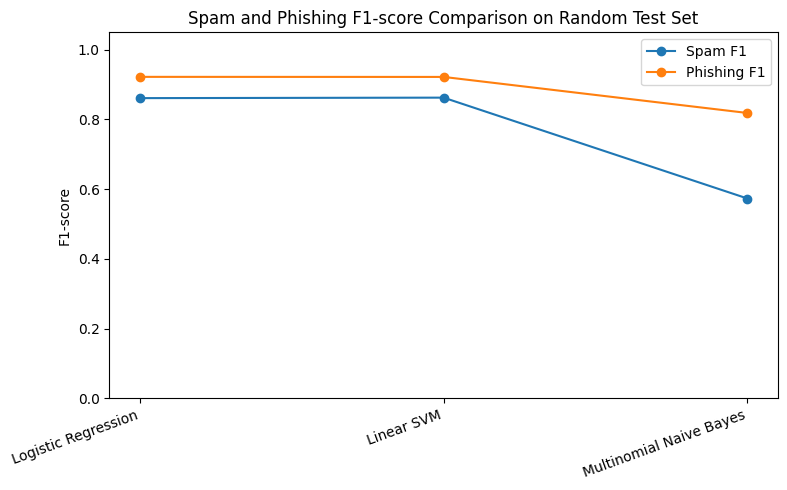

In [ ]:
# Step 10.4: Plot spam and phishing F1-score comparison

spam_phishing_plot = spam_phishing_comparison[[
    "Model",
    "Spam F1",
    "Phishing F1"
]].copy()

plt.figure(figsize=(8, 5))

plt.plot(
    spam_phishing_plot["Model"],
    spam_phishing_plot["Spam F1"],
    marker="o",
    label="Spam F1"
)

plt.plot(
    spam_phishing_plot["Model"],
    spam_phishing_plot["Phishing F1"],
    marker="o",
    label="Phishing F1"
)

plt.ylabel("F1-score")
plt.title("Spam and Phishing F1-score Comparison on Random Test Set")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()

plt.show()

## Observations from Random Test Evaluation and Class-Level Comparison

The random test results show that Linear SVM and Logistic Regression perform strongly under conventional random train-test split conditions. Linear SVM achieved the highest random test accuracy and macro F1-score, while Logistic Regression achieved slightly higher phishing recall and phishing F1-score.

The spam and phishing class comparison also shows that Logistic Regression and Linear SVM perform strongly across both spam and phishing classes. This supports the value of treating the task as a three-class email classification problem rather than only a binary phishing/not-phishing problem.

Multinomial Naive Bayes remains useful as a baseline model and achieved useful phishing recall, but its lower spam F1-score and macro F1-score indicate weaker balance across the three classes under random test conditions.

At this stage, the results are interpreted only as random test performance. Final conclusions require comparison with the untouched OOD phishing-only split and false negative analysis.

# Step 11: OOD Robustness Evaluation Across Baseline Models

This section evaluates all three baseline models on the untouched OOD split.

The models were trained using the random training set and evaluated first on the random test set. The OOD split was kept separate during random train-test splitting and is now used for robustness evaluation.

The OOD split contains phishing emails only. Therefore, this evaluation is interpreted as a phishing robustness test rather than a standard multi-class test.

In [ ]:
# Step 11.1: Define OOD phishing robustness evaluation function

def evaluate_ood_phishing(model_name, y_true, y_pred):
    """
    Evaluate model performance on the OOD phishing-only split.

    Since the OOD split contains phishing emails only, phishing recall
    and missed phishing count are the most meaningful metrics.
    """

    total_ood_records = len(y_true)
    actual_phishing_count = (y_true == 2).sum()

    predicted_legitimate_count = (y_pred == 0).sum()
    predicted_spam_count = (y_pred == 1).sum()
    predicted_phishing_count = (y_pred == 2).sum()

    detected_phishing_count = ((y_true == 2) & (y_pred == 2)).sum()
    missed_phishing_count = actual_phishing_count - detected_phishing_count

    phishing_recall = detected_phishing_count / actual_phishing_count
    missed_phishing_rate = missed_phishing_count / actual_phishing_count

    summary = {
        "Model": model_name,
        "Total OOD Records": total_ood_records,
        "Actual Phishing Records": actual_phishing_count,
        "Predicted Legitimate": predicted_legitimate_count,
        "Predicted Spam": predicted_spam_count,
        "Predicted Phishing": predicted_phishing_count,
        "Detected Phishing": detected_phishing_count,
        "Missed Phishing": missed_phishing_count,
        "OOD Phishing Recall": phishing_recall,
        "OOD Missed Phishing Rate": missed_phishing_rate
    }

    prediction_distribution = pd.DataFrame({
        "Predicted Class": ["Legitimate", "Spam", "Phishing"],
        "Record Count": [
            predicted_legitimate_count,
            predicted_spam_count,
            predicted_phishing_count
        ]
    })

    print(f"OOD phishing robustness evaluation for {model_name}:")
    display(prediction_distribution)

    return summary

In [ ]:
# Step 11.2: Evaluate all baseline models on the OOD split

ood_results_all_models = {}
ood_predictions_all_models = {}

for model_name, model in all_baseline_models.items():
    print("=" * 80)
    print(f"OOD evaluation for {model_name}")
    print("=" * 80)

    # Predict OOD labels
    y_ood_pred = model.predict(X_ood_tfidf)

    # Store predictions for later analysis
    ood_predictions_all_models[model_name] = y_ood_pred

    # Evaluate OOD phishing robustness
    ood_results_all_models[model_name] = evaluate_ood_phishing(
        model_name,
        y_ood,
        y_ood_pred
    )

ood_summary_all_models = pd.DataFrame(ood_results_all_models.values()).round(4)

ood_ranking = ood_summary_all_models.sort_values(
    by=["OOD Phishing Recall", "Missed Phishing"],
    ascending=[False, True]
).reset_index(drop=True)

ood_ranking["OOD Rank"] = ood_ranking.index + 1

display(ood_ranking)

OOD evaluation for Multinomial Naive Bayes
OOD phishing robustness evaluation for Multinomial Naive Bayes:


,Predicted Class,Record Count
0,Legitimate,403
1,Spam,228
2,Phishing,1810


OOD evaluation for Logistic Regression
OOD phishing robustness evaluation for Logistic Regression:


,Predicted Class,Record Count
0,Legitimate,226
1,Spam,1958
2,Phishing,257


OOD evaluation for Linear SVM
OOD phishing robustness evaluation for Linear SVM:


,Predicted Class,Record Count
0,Legitimate,172
1,Spam,1874
2,Phishing,395


,Model,Total OOD Records,Actual Phishing Records,Predicted Legitimate,Predicted Spam,Predicted Phishing,Detected Phishing,Missed Phishing,OOD Phishing Recall,OOD Missed Phishing Rate,OOD Rank
0,Multinomial Naive Bayes,2441,2441,403,228,1810,1810,631,0.7415,0.2585,1
1,Linear SVM,2441,2441,172,1874,395,395,2046,0.1618,0.8382,2
2,Logistic Regression,2441,2441,226,1958,257,257,2184,0.1053,0.8947,3


In [ ]:
# Step 11.3: Compact comparison of random test phishing recall and OOD phishing recall

random_test_ood_comparison = random_test_summary[
    ["Model", "Phishing Recall", "Phishing F1"]
].copy()

random_test_ood_comparison = random_test_ood_comparison.merge(
    ood_summary_all_models[
        ["Model", "OOD Phishing Recall", "OOD Missed Phishing Rate", "Missed Phishing"]
    ],
    on="Model"
)

random_test_ood_comparison["Phishing Recall Drop"] = (
    random_test_ood_comparison["Phishing Recall"] -
    random_test_ood_comparison["OOD Phishing Recall"]
).round(4)

random_test_ood_comparison = random_test_ood_comparison.rename(columns={
    "Phishing Recall": "Random Test Phishing Recall",
    "Phishing F1": "Random Test Phishing F1"
})

random_test_ood_comparison = random_test_ood_comparison.sort_values(
    by=["OOD Phishing Recall", "Missed Phishing"],
    ascending=[False, True]
).reset_index(drop=True)

display(random_test_ood_comparison.round(4))

,Model,Random Test Phishing Recall,Random Test Phishing F1,OOD Phishing Recall,OOD Missed Phishing Rate,Missed Phishing,Phishing Recall Drop
0,Multinomial Naive Bayes,0.9085,0.8187,0.7415,0.2585,631,0.1670
1,Linear SVM,0.9572,0.9221,0.1618,0.8382,2046,0.7954
2,Logistic Regression,0.9578,0.9223,0.1053,0.8947,2184,0.8525


## Observations from OOD Robustness Evaluation

The OOD split was kept separate during the random train-test split and was used only after model training and random test evaluation.

The compact random test-OOD comparison shows whether strong random test phishing recall translates into strong OOD phishing recall. A large recall drop would indicate that conventional random split performance does not necessarily reflect robustness under shifted phishing conditions.

This result directly supports the dissertation aim of developing AI-based phishing detection models and evaluating whether their performance remains reliable beyond standard test-set evaluation.

# Step 12: Complete Random Test and OOD Comparison

This section combines the random test results with the OOD phishing robustness results.

The purpose is to compare conventional random train-test split performance with OOD phishing performance. This helps assess whether models that perform strongly under standard random test evaluation also remain reliable when tested on phishing emails from the separate OOD split.

In [ ]:
# Step 12.1: Create complete random test and OOD comparison table

random_test_comparison = random_test_summary[[
    "Model",
    "Accuracy",
    "Macro F1",
    "Phishing Recall",
    "Phishing F1"
]].rename(columns={
    "Accuracy": "Random Test Accuracy",
    "Macro F1": "Random Test Macro F1",
    "Phishing Recall": "Random Test Phishing Recall",
    "Phishing F1": "Random Test Phishing F1"
})

ood_comparison = ood_summary_all_models[[
    "Model",
    "OOD Phishing Recall",
    "OOD Missed Phishing Rate",
    "Missed Phishing"
]]

complete_random_test_ood_comparison = (
    random_test_comparison
    .merge(ood_comparison, on="Model")
)

complete_random_test_ood_comparison["Random Test to OOD Phishing Recall Drop"] = (
    complete_random_test_ood_comparison["Random Test Phishing Recall"] -
    complete_random_test_ood_comparison["OOD Phishing Recall"]
).round(4)

complete_random_test_ood_comparison = complete_random_test_ood_comparison.sort_values(
    by=["OOD Phishing Recall", "Missed Phishing"],
    ascending=[False, True]
).reset_index(drop=True)

display(complete_random_test_ood_comparison.round(4))

,Model,Random Test Accuracy,Random Test Macro F1,Random Test Phishing Recall,Random Test Phishing F1,OOD Phishing Recall,OOD Missed Phishing Rate,Missed Phishing,Random Test to OOD Phishing Recall Drop
0,Multinomial Naive Bayes,0.8253,0.7726,0.9085,0.8187,0.7415,0.2585,631,0.1670
1,Linear SVM,0.9279,0.9164,0.9572,0.9221,0.1618,0.8382,2046,0.7954
2,Logistic Regression,0.9272,0.9156,0.9578,0.9223,0.1053,0.8947,2184,0.8525


In [ ]:
# Step 12.2: Create concise main finding summary table

main_finding_summary = complete_random_test_ood_comparison[[
    "Model",
    "Random Test Macro F1",
    "Random Test Phishing Recall",
    "OOD Phishing Recall",
    "Random Test to OOD Phishing Recall Drop",
    "Missed Phishing"
]].copy()

display(main_finding_summary.round(4))

,Model,Random Test Macro F1,Random Test Phishing Recall,OOD Phishing Recall,Random Test to OOD Phishing Recall Drop,Missed Phishing
0,Multinomial Naive Bayes,0.7726,0.9085,0.7415,0.1670,631
1,Linear SVM,0.9164,0.9572,0.1618,0.7954,2046
2,Logistic Regression,0.9156,0.9578,0.1053,0.8525,2184


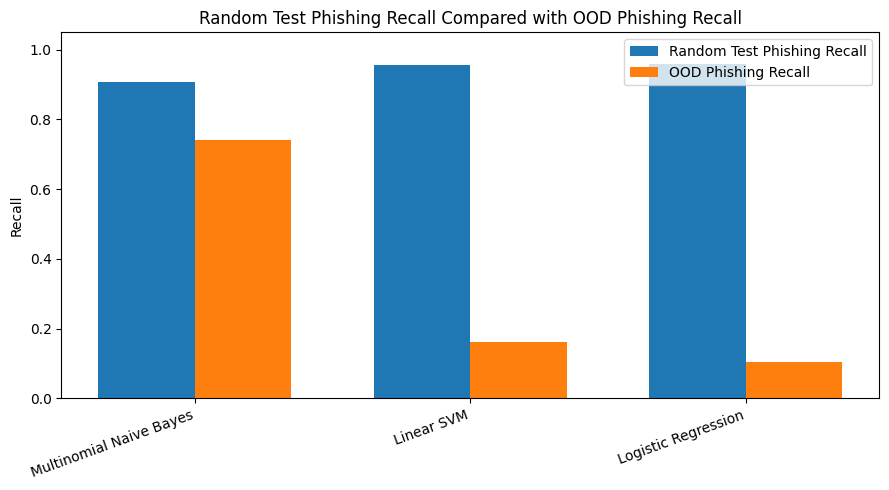

In [ ]:
# Step 12.3: Plot random test phishing recall against OOD phishing recall

plot_recall_comparison = complete_random_test_ood_comparison[[
    "Model",
    "Random Test Phishing Recall",
    "OOD Phishing Recall"
]].copy()

x_positions = np.arange(len(plot_recall_comparison))
bar_width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x_positions - bar_width / 2,
    plot_recall_comparison["Random Test Phishing Recall"],
    bar_width,
    label="Random Test Phishing Recall"
)

plt.bar(
    x_positions + bar_width / 2,
    plot_recall_comparison["OOD Phishing Recall"],
    bar_width,
    label="OOD Phishing Recall"
)

plt.xticks(x_positions, plot_recall_comparison["Model"], rotation=20, ha="right")
plt.ylabel("Recall")
plt.title("Random Test Phishing Recall Compared with OOD Phishing Recall")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

plt.show()

## Observations from Complete Random Test and OOD Comparison

The complete comparison shows that model performance depends strongly on the evaluation condition.

Linear SVM and Logistic Regression achieved the strongest performance under the conventional random train-test split. Their random test accuracy, macro F1-score and phishing recall were higher than Multinomial Naive Bayes.

However, the OOD phishing-only evaluation showed a different pattern. Multinomial Naive Bayes achieved the strongest OOD phishing recall and missed fewer OOD phishing emails than Linear SVM and Logistic Regression.

The graph reinforces this difference visually. Linear SVM and Logistic Regression achieved high phishing recall on the random test set, but both suffered large drops on the OOD phishing-only split. Multinomial Naive Bayes showed a smaller drop and achieved the strongest OOD phishing recall.

This result supports the dissertation argument that AI-based phishing detection models should not be judged only by standard random test performance. Robustness-focused OOD evaluation provides additional evidence about model reliability.

## OOD Evaluation Interpretation Note

The dataset-provided OOD split contains phishing-labelled emails only. Therefore, it is not treated as a full multi-class OOD test set.

Instead, the OOD split is used as a phishing-only robustness stress test. The purpose is to assess whether trained models can still identify phishing emails that are separated from the main random train-test data.

As a result, OOD phishing recall and missed phishing count are interpreted as robustness indicators. They are not used alone to claim that one model is the best overall model for all email classes.

# Step 13: Security-Focused False Negative Analysis

This section analyses phishing false negatives across the random test set and the OOD split.

In phishing detection, false negatives are especially important because they represent phishing emails that the model failed to identify as phishing. These missed phishing emails may be incorrectly classified as legitimate or spam.

This analysis supports the dissertation focus on security-relevant evaluation rather than relying only on overall random test accuracy.

In [ ]:
# Step 13.1: Define phishing false negative analysis function

def phishing_false_negative_summary(model_name, evaluation_name, y_true, y_pred):
    """
    Summarise phishing detection errors for a given model and evaluation split.

    A phishing false negative is an actual phishing email that is predicted
    as either legitimate or spam.
    """

    actual_phishing_mask = (y_true == 2)
    actual_phishing_count = actual_phishing_mask.sum()

    detected_phishing_count = ((y_true == 2) & (y_pred == 2)).sum()
    missed_as_legitimate = ((y_true == 2) & (y_pred == 0)).sum()
    missed_as_spam = ((y_true == 2) & (y_pred == 1)).sum()

    total_missed_phishing = missed_as_legitimate + missed_as_spam

    phishing_recall = detected_phishing_count / actual_phishing_count
    phishing_missed_rate = total_missed_phishing / actual_phishing_count

    return {
        "Model": model_name,
        "Evaluation Split": evaluation_name,
        "Actual Phishing Records": actual_phishing_count,
        "Detected as Phishing": detected_phishing_count,
        "Missed as Legitimate": missed_as_legitimate,
        "Missed as Spam": missed_as_spam,
        "Total Missed Phishing": total_missed_phishing,
        "Phishing Recall": phishing_recall,
        "Phishing Missed Rate": phishing_missed_rate
    }

In [ ]:
# Step 13.2: Analyse phishing false negatives across random test and OOD splits

false_negative_rows = []

for model_name in all_baseline_models.keys():

    # Random test split false negative analysis
    false_negative_rows.append(
        phishing_false_negative_summary(
            model_name,
            "Random Test",
            y_test,
            random_test_predictions[model_name]
        )
    )

    # OOD split false negative analysis
    false_negative_rows.append(
        phishing_false_negative_summary(
            model_name,
            "OOD",
            y_ood,
            ood_predictions_all_models[model_name]
        )
    )

false_negative_summary = pd.DataFrame(false_negative_rows).round(4)

display(false_negative_summary)

,Model,Evaluation Split,Actual Phishing Records,Detected as Phishing,Missed as Legitimate,Missed as Spam,Total Missed Phishing,Phishing Recall,Phishing Missed Rate
0,Multinomial Naive Bayes,Random Test,11512,10459,759,294,1053,0.9085,0.0915
1,Multinomial Naive Bayes,OOD,2441,1810,403,228,631,0.7415,0.2585
2,Logistic Regression,Random Test,11512,11026,218,268,486,0.9578,0.0422
3,Logistic Regression,OOD,2441,257,226,1958,2184,0.1053,0.8947
4,Linear SVM,Random Test,11512,11019,224,269,493,0.9572,0.0428
5,Linear SVM,OOD,2441,395,172,1874,2046,0.1618,0.8382


In [ ]:
# Step 13.3: Create compact false negative comparison table

compact_false_negative_summary = false_negative_summary[[
    "Model",
    "Evaluation Split",
    "Actual Phishing Records",
    "Detected as Phishing",
    "Missed as Legitimate",
    "Missed as Spam",
    "Total Missed Phishing",
    "Phishing Recall",
    "Phishing Missed Rate"
]].copy()

compact_false_negative_summary = compact_false_negative_summary.sort_values(
    by=["Evaluation Split", "Phishing Recall"],
    ascending=[True, False]
).reset_index(drop=True)

display(compact_false_negative_summary)

,Model,Evaluation Split,Actual Phishing Records,Detected as Phishing,Missed as Legitimate,Missed as Spam,Total Missed Phishing,Phishing Recall,Phishing Missed Rate
0,Multinomial Naive Bayes,OOD,2441,1810,403,228,631,0.7415,0.2585
1,Linear SVM,OOD,2441,395,172,1874,2046,0.1618,0.8382
2,Logistic Regression,OOD,2441,257,226,1958,2184,0.1053,0.8947
3,Logistic Regression,Random Test,11512,11026,218,268,486,0.9578,0.0422
4,Linear SVM,Random Test,11512,11019,224,269,493,0.9572,0.0428
5,Multinomial Naive Bayes,Random Test,11512,10459,759,294,1053,0.9085,0.0915


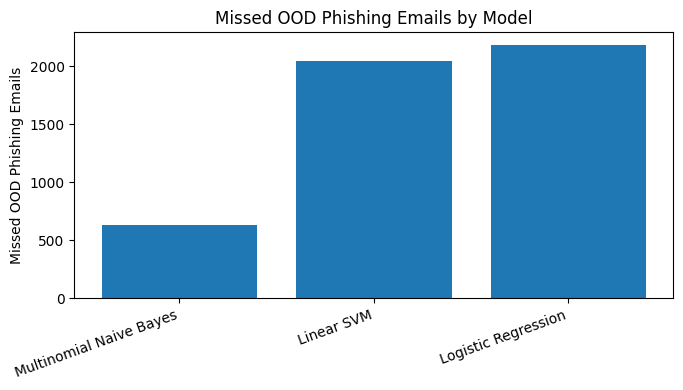

In [ ]:
# Step 13.4: Plot missed OOD phishing emails by model

ood_false_negative_plot = compact_false_negative_summary[
    compact_false_negative_summary["Evaluation Split"] == "OOD"
][[
    "Model",
    "Total Missed Phishing"
]].copy()

ood_false_negative_plot = ood_false_negative_plot.sort_values(
    by="Total Missed Phishing",
    ascending=True
).reset_index(drop=True)

plt.figure(figsize=(7, 4))

plt.bar(
    ood_false_negative_plot["Model"],
    ood_false_negative_plot["Total Missed Phishing"]
)

plt.ylabel("Missed OOD Phishing Emails")
plt.title("Missed OOD Phishing Emails by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.show()

## Observations from Security-Focused False Negative Analysis

The false negative analysis focuses on phishing emails that were not identified as phishing. This is important because missed phishing emails represent a higher security risk than many ordinary classification errors.

On the random test set, Logistic Regression and Linear SVM missed relatively few phishing emails, which is consistent with their high random test phishing recall. Multinomial Naive Bayes missed more phishing emails on the random test set, reflecting its weaker conventional random test performance.

The OOD split shows a different pattern. Multinomial Naive Bayes missed fewer OOD phishing emails than Logistic Regression and Linear SVM, even though it performed worse under random test conditions. The graph reinforces this security-focused difference by showing that the two stronger conventional models missed a much larger number of OOD phishing emails.

This result supports the dissertation argument that AI-based phishing detection models should be evaluated using security-relevant metrics such as phishing recall, missed phishing count and false negative rate, rather than relying on random test accuracy alone.

# Step 14: Save TEST_SPLIT Model Artefacts and Result Tables

This section saves the trained models, TF-IDF vectoriser and key result tables from the random train-test split experiment.

Saving these artefacts supports reproducibility and allows the TEST_SPLIT experiment outputs to be reviewed separately from the predefined-split experiment.# Step 14: Security-Focused False Negative Analysis

This section analyses phishing false negatives across the held-out test set and the OOD split.

In phishing detection, false negatives are especially important because they represent phishing emails that the model failed to identify as phishing. These missed phishing emails may be incorrectly classified as legitimate or spam.

This analysis supports the dissertation focus on security-relevant evaluation rather than relying only on overall accuracy.

In [ ]:
# Step 14.1: Create output folders for TEST_SPLIT results and model artefacts

results_dir = Path("/content/drive/MyDrive/MSc_Dissertation/05_Results/TEST_SPLIT_11082026")
artefacts_dir = Path("/content/drive/MyDrive/MSc_Dissertation/06_Model_Artefacts/TEST_SPLIT_11082026")

results_dir.mkdir(parents=True, exist_ok=True)
artefacts_dir.mkdir(parents=True, exist_ok=True)

print(f"Results folder: {results_dir}")
print(f"Model artefacts folder: {artefacts_dir}")

Results folder: /content/drive/MyDrive/MSc_Dissertation/05_Results/TEST_SPLIT_11082026
Model artefacts folder: /content/drive/MyDrive/MSc_Dissertation/06_Model_Artefacts/TEST_SPLIT_11082026


In [ ]:
# Step 14.2: Save key TEST_SPLIT result tables as CSV files

tables_to_save = {
    "random_test_summary.csv": random_test_summary,
    "random_test_ranking.csv": random_test_ranking,
    "spam_phishing_comparison.csv": spam_phishing_comparison,
    "ood_summary_all_models.csv": ood_summary_all_models,
    "ood_ranking.csv": ood_ranking,
    "random_test_ood_comparison.csv": random_test_ood_comparison,
    "complete_random_test_ood_comparison.csv": complete_random_test_ood_comparison,
    "main_finding_summary.csv": main_finding_summary,
    "false_negative_summary.csv": false_negative_summary,
    "compact_false_negative_summary.csv": compact_false_negative_summary
}

for file_name, table in tables_to_save.items():
    output_path = results_dir / file_name
    table.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/TEST_SPLIT_11082026/random_test_summary.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/TEST_SPLIT_11082026/random_test_ranking.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/TEST_SPLIT_11082026/spam_phishing_comparison.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/TEST_SPLIT_11082026/ood_summary_all_models.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/TEST_SPLIT_11082026/ood_ranking.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/TEST_SPLIT_11082026/random_test_ood_comparison.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/TEST_SPLIT_11082026/complete_random_test_ood_comparison.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/TEST_SPLIT_11082026/main_finding_summary.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/TEST_SPLIT_11082026/false_negative_summary.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Resul

In [ ]:
# Step 14.3: Save TF-IDF vectoriser and trained models

model_artefacts = {
    "tfidf_vectorizer_test_split.joblib": tfidf_vectorizer,
    "multinomial_naive_bayes_model_test_split.joblib": nb_model,
    "logistic_regression_model_test_split.joblib": lr_model,
    "linear_svm_model_test_split.joblib": svm_model,
    "label_mapping.joblib": label_mapping
}

for file_name, artefact in model_artefacts.items():
    output_path = artefacts_dir / file_name
    joblib.dump(artefact, output_path)
    print(f"Saved: {output_path}")

Saved: /content/drive/MyDrive/MSc_Dissertation/06_Model_Artefacts/TEST_SPLIT_11082026/tfidf_vectorizer_test_split.joblib
Saved: /content/drive/MyDrive/MSc_Dissertation/06_Model_Artefacts/TEST_SPLIT_11082026/multinomial_naive_bayes_model_test_split.joblib
Saved: /content/drive/MyDrive/MSc_Dissertation/06_Model_Artefacts/TEST_SPLIT_11082026/logistic_regression_model_test_split.joblib
Saved: /content/drive/MyDrive/MSc_Dissertation/06_Model_Artefacts/TEST_SPLIT_11082026/linear_svm_model_test_split.joblib
Saved: /content/drive/MyDrive/MSc_Dissertation/06_Model_Artefacts/TEST_SPLIT_11082026/label_mapping.joblib


In [ ]:
# Step 14.4: Save concise TEST_SPLIT experiment summary as a text file

summary_lines = [
    "AI-Based Phishing Email Detection TEST_SPLIT Experiment Summary",
    "",
    f"Dataset records: {df.shape[0]}",
    f"Dataset columns: {df.shape[1]}",
    "",
    "Experiment design:",
    "- OOD records were kept separate.",
    "- Non-OOD records were combined and split using train_test_split.",
    "- TF-IDF was fitted only on the random training set.",
    "",
    "Models evaluated:",
    "- Multinomial Naive Bayes",
    "- Logistic Regression",
    "- Linear SVM",
    "",
    "Main finding summary:",
]

for _, row in main_finding_summary.iterrows():
    summary_lines.append(
        f"- {row['Model']}: "
        f"Random test phishing recall = {row['Random Test Phishing Recall']:.4f}, "
        f"OOD phishing recall = {row['OOD Phishing Recall']:.4f}, "
        f"missed OOD phishing emails = {int(row['Missed Phishing'])}"
    )

summary_lines.extend([
    "",
    "Interpretation:",
    "The strongest random test models were not necessarily the most robust on the OOD phishing-only split.",
    "This supports the dissertation focus on AI-based phishing detection with robustness-focused evaluation."
])

summary_path = results_dir / "test_split_experiment_summary.txt"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

print(f"Saved: {summary_path}")

Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/TEST_SPLIT_11082026/test_split_experiment_summary.txt


In [ ]:
# Step 14.5: Confirm saved result and artefact files

saved_results = pd.DataFrame({
    "Saved Result File": sorted([file.name for file in results_dir.iterdir() if file.is_file()])
})

saved_artefacts = pd.DataFrame({
    "Saved Artefact File": sorted([file.name for file in artefacts_dir.iterdir() if file.is_file()])
})

print("Saved result files:")
display(saved_results)

print("Saved model artefact files:")
display(saved_artefacts)

Saved result files:


,Saved Result File
0,compact_false_negative_summary.csv
1,complete_random_test_ood_comparison.csv
2,false_negative_summary.csv
3,main_finding_summary.csv
4,ood_ranking.csv
5,ood_summary_all_models.csv
6,random_test_ood_comparison.csv
7,random_test_ranking.csv
8,random_test_summary.csv
9,spam_phishing_comparison.csv


Saved model artefact files:


,Saved Artefact File
0,label_mapping.joblib
1,linear_svm_model_test_split.joblib
2,logistic_regression_model_test_split.joblib
3,multinomial_naive_bayes_model_test_split.joblib
4,tfidf_vectorizer_test_split.joblib


## Observations from Saving TEST_SPLIT Artefacts and Result Tables

The trained models, TF-IDF vectoriser, label mapping and key result tables from the TEST_SPLIT experiment were saved to Google Drive.

The saved CSV files provide evidence for the random test evaluation, OOD robustness comparison and false negative analysis. These outputs can be used later when comparing the predefined-split and random-split experiments in the dissertation.

All three trained models were saved because the dissertation compares model behaviour across evaluation conditions rather than relying only on a single final model.

# Step 15: Final TEST_SPLIT Experiment Summary and Dissertation Finding

This final section summarises the main findings from the random train-test split experiment.

The purpose is to connect the technical results back to the dissertation aim: developing AI-based phishing email detection models and evaluating whether their performance remains reliable under standard random test conditions and OOD phishing conditions.

In [ ]:
# Step 15.1: Display final main finding table

display(main_finding_summary.round(4))

,Model,Random Test Macro F1,Random Test Phishing Recall,OOD Phishing Recall,Random Test to OOD Phishing Recall Drop,Missed Phishing
0,Multinomial Naive Bayes,0.7726,0.9085,0.7415,0.1670,631
1,Linear SVM,0.9164,0.9572,0.1618,0.7954,2046
2,Logistic Regression,0.9156,0.9578,0.1053,0.8525,2184


In [ ]:
# Step 15.2: Generate final TEST_SPLIT experiment interpretation

best_random_test_model = random_test_ranking.sort_values(
    by=["Macro F1", "Phishing F1", "Phishing Recall", "Accuracy"],
    ascending=False
).iloc[0]["Model"]

best_ood_model = ood_ranking.sort_values(
    by=["OOD Phishing Recall", "Missed Phishing"],
    ascending=[False, True]
).iloc[0]["Model"]

print("Final TEST_SPLIT experiment interpretation")
print("=" * 80)
print(f"Best model under random test evaluation: {best_random_test_model}")
print(f"Best model under OOD phishing recall evaluation: {best_ood_model}")
print()
print("Main dissertation finding:")
print(
    "The strongest model under conventional random train-test evaluation "
    "was not necessarily the most robust model under OOD phishing conditions."
)
print()
print("Implication:")
print(
    "AI-based phishing email detection models should be evaluated using both "
    "standard random test metrics and robustness-focused measures such as "
    "OOD phishing recall, missed phishing count and phishing false negative rate."
)

Final TEST_SPLIT experiment interpretation
Best model under random test evaluation: Linear SVM
Best model under OOD phishing recall evaluation: Multinomial Naive Bayes

Main dissertation finding:
The strongest model under conventional random train-test evaluation was not necessarily the most robust model under OOD phishing conditions.

Implication:
AI-based phishing email detection models should be evaluated using both standard random test metrics and robustness-focused measures such as OOD phishing recall, missed phishing count and phishing false negative rate.


In [ ]:
# Step 15.3: Create final TEST_SPLIT notebook summary table

final_notebook_summary = pd.DataFrame({
    "Experiment Area": [
        "Dataset inspection",
        "OOD separation",
        "Random train-test split",
        "Feature extraction",
        "Baseline models",
        "Random test evaluation",
        "OOD robustness evaluation",
        "False negative analysis",
        "Saved artefacts"
    ],
    "Completed Output": [
        "Dataset shape, labels, split structure, missing values and campaign-related checks",
        "OOD phishing records kept separate from random train-test splitting",
        "Non-OOD records split using train_test_split with stratified labels",
        "TF-IDF vectorisation fitted only on random training data",
        "Multinomial Naive Bayes, Logistic Regression and Linear SVM",
        "Comparison of conventional random test performance across all models",
        "Phishing-only OOD recall and missed phishing analysis",
        "Security-focused analysis of phishing emails missed by each model",
        "Models, TF-IDF vectoriser, result tables and experiment summary saved to Google Drive"
    ]
})

display(final_notebook_summary)

,Experiment Area,Completed Output
0,Dataset inspection,"Dataset shape, labels, split structure, missing values and campaign-related checks"
1,OOD separation,OOD phishing records kept separate from random train-test splitting
2,Random train-test split,Non-OOD records split using train_test_split with stratified labels
3,Feature extraction,TF-IDF vectorisation fitted only on random training data
4,Baseline models,"Multinomial Naive Bayes, Logistic Regression and Linear SVM"
5,Random test evaluation,Comparison of conventional random test performance across all models
6,OOD robustness evaluation,Phishing-only OOD recall and missed phishing analysis
7,False negative analysis,Security-focused analysis of phishing emails missed by each model
8,Saved artefacts,"Models, TF-IDF vectoriser, result tables and experiment summary saved to Google Drive"


## Final TEST_SPLIT Experiment Summary

The TEST_SPLIT experiment developed and evaluated three baseline machine-learning models for phishing email detection: Multinomial Naive Bayes, Logistic Regression and Linear SVM. All models used TF-IDF features extracted from email text.

In this experiment, the OOD split was kept separate. The remaining non-OOD records were combined and divided using a random train-test split. This allowed the experiment to compare conventional random test performance with OOD phishing robustness.

The random test results showed that Linear SVM and Logistic Regression achieved the strongest conventional classification performance. Linear SVM achieved the highest random test accuracy and macro F1-score, while Logistic Regression achieved slightly higher phishing recall and phishing F1-score.

However, the OOD phishing-only evaluation showed a different pattern. Multinomial Naive Bayes achieved substantially higher OOD phishing recall than Logistic Regression and Linear SVM, despite having weaker random test performance.

Because the OOD split contains phishing-labelled emails only, it is interpreted as a phishing-only robustness stress test rather than a full multi-class OOD evaluation.

This result is central to the dissertation. It shows that strong random test performance does not necessarily prove robustness under OOD phishing conditions. The experiment therefore supports the argument that AI-based phishing email detection models should be evaluated using conventional metrics, OOD robustness testing and security-focused false negative analysis.

Linear SVM and Logistic Regression performed best under random test evaluation, while Multinomial Naive Bayes achieved stronger phishing recall on the phishing-only OOD split.

## Appendix: Supplementary Dataset Understanding Checks

In [ ]:
# Check all actual split values in the dataset

split_values = (
    df["split"]
    .astype(str)
    .str.lower()
    .value_counts()
    .reset_index()
)

split_values.columns = ["Split", "Record Count"]
split_values["Percentage"] = (
    split_values["Record Count"] / len(df) * 100
).round(2)

display(split_values)

In [ ]:
# Check label distribution inside each split

split_label_distribution = pd.crosstab(
    df["split"].astype(str).str.lower(),
    df["label"]
)

split_label_distribution = split_label_distribution.rename(columns={
    0: "Legitimate",
    1: "Spam",
    2: "Phishing"
})

display(split_label_distribution)

In [ ]:
# Understand campaign_fingerprint grouping

campaign_summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Unique campaign_fingerprint values",
        "Average records per campaign_fingerprint",
        "Largest campaign_fingerprint group"
    ],
    "Value": [
        len(df),
        df["campaign_fingerprint"].nunique(),
        round(len(df) / df["campaign_fingerprint"].nunique(), 2),
        df["campaign_fingerprint"].value_counts().max()
    ]
})

display(campaign_summary)